# Global Flood Database v1 (2000-2018)

**Preferred batch path:**

```bash
python transformation/global_flood_database/extract_gfd.py --site plymouth
```

This notebook remains useful for interactive maps / histograms. Exports land under `flood_hazard/sites/<city>/data/input/`.

Dataset Availability
- 2000-02-17 TO 2018-12-10

Pixel size
- 30 meters (all bands)

Dataset Availability
- 2000-02-17 TO 2018-12-10

Pixel size
- 30 meters (all bands)

Dataset Producer
- Cloud to Street (C2S) / Dartmouth Flood Observatory (DFO)

Terms of Use
- This work is licensed under the Creative Commons Attribution Non Commercial 4.0 International license.


In [1]:
# Site configuration — uses transformation/flood_hazard city configs
import os
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
_FLOOD_HAZARD = None
for _candidate in [_HERE, *_HERE.parents]:
    _probe = _candidate / "flood_hazard" if _candidate.name != "flood_hazard" else _candidate
    if (_probe / "site_config.py").is_file() and (_probe / "config" / "sites").is_dir():
        _FLOOD_HAZARD = _probe
        break
if _FLOOD_HAZARD is None:
    raise FileNotFoundError("Could not locate transformation/flood_hazard from notebook cwd")

sys.path.insert(0, str(_FLOOD_HAZARD))
from site_config import configured_path, load_site_config

FLOOD_HAZARD_ROOT = _FLOOD_HAZARD
FLOODS_ROOT = FLOOD_HAZARD_ROOT  # backward-compatible alias

# Set the city here (edit this line). That value wins for interactive runs.
# Use None to fall back to env FLOODS_SITE (default porto_alegre).
SITE_SLUG = "plymouth"  # or: "porto_alegre" | "edina" | "richfield" | "rochester" | "apple_valley" | None
if SITE_SLUG is None:
    SITE_SLUG = os.environ.get("FLOODS_SITE", "porto_alegre")
SITE_CONFIG = load_site_config(SITE_SLUG, FLOOD_HAZARD_ROOT)
SITE_ROOT = SITE_CONFIG["paths_abs"]["site_root"]
INPUT_DIR = SITE_CONFIG["paths_abs"]["data_input"]
INTERMEDIATE_DIR = SITE_CONFIG["paths_abs"]["data_intermediate"]
OUTPUT_DIR = SITE_CONFIG["paths_abs"]["data_output"]
OUT_ROOT = SITE_CONFIG["paths_abs"]["out"]
CACHE_DIR = SITE_CONFIG["paths_abs"]["cache"]
STYLES_DIR = SITE_CONFIG["paths_abs"]["styles"]
OUTPUT_PREFIX = SITE_CONFIG["output_prefix"]
print(f"Flood hazard site: {SITE_CONFIG['display_name']} ({SITE_SLUG})")
print(f"Config: {SITE_CONFIG['config_path']}")
print(f"Inputs -> {INPUT_DIR}")


Flood hazard site: Plymouth (plymouth)
Config: /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/config/sites/plymouth.yaml
Inputs -> /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input


## Methodology


### What this dataset represents
- `GLOBAL_FLOOD_DB/MODIS_EVENTS/V1` contains mapped historical flood events (2000-2018) derived from MODIS.
- Each image corresponds to one specific flood event.

### How to interpret `flooded = 1`
- `flooded = 1` does **not** mean a pixel is permanently flood-prone.
- It means that, during that specific event, the pixel was observed as water at some point.

### How to identify zones more prone to observed flooding
- A practical approach is to aggregate events by summing `flooded` across the collection.
- This produces `flood_event_count`: number of events in which each pixel was observed flooded.

### Important caveat
- This sum is **not** a true probabilistic frequency.
- It is an **observed frequency within the mapped event catalog** (i.e., event-occurrence count in the database).

### Operational choice used here
- Exclude permanent water (`jrc_perm_water == 1`) before summing.
- Output interpretation: areas observed flooded at least once between 2000 and 2018 (excluding permanent water bodies).

### Normalization applied to flood_event_count_no_perm_water (0–1)

The original indicator is a count of observed events per pixel (not a probability), with a distribution that is typically skewed (many zeros and few high values).
To prevent a few outliers from dominating the result, a robust normalization is applied in 3 steps:
1) 95th percentile (p95) winsorization: extreme values are clipped (count_capped = min(count, p95)).
2) Logarithmic compression: log1p(count_capped) to reduce asymmetry and improve spatial comparability.
3) Min-max scaling on the log-transformed layer, within the ROI, to obtain values in [0,1].

**Interpretation:** 0 indicates the lowest relative flood signal observed in the catalog; 1 indicates a high relative signal within the analysis area.

**Important:** this result represents normalized observed frequency, not physical probability of flooding.


## Work


In [2]:
import geemap
import ee

In [3]:
# Access Earth Engine
ee.Authenticate()
ee.Initialize(
    project='eecc-maureen',
    opt_url='https://earthengine-highvolume.googleapis.com'
)

In [4]:
# Site ROI: use the site polygon when available; fall back to bbox.
import json


def load_site_roi() -> ee.Geometry:
    boundary_path = SITE_CONFIG["boundary_path_abs"]
    if boundary_path.exists():
        data = json.loads(boundary_path.read_text())
        if data.get("type") == "FeatureCollection":
            features = [
                ee.Feature(ee.Geometry(feature["geometry"]), feature.get("properties", {}))
                for feature in data.get("features", [])
                if feature.get("geometry")
            ]
            if features:
                return ee.FeatureCollection(features).geometry()
        if data.get("type") == "Feature":
            return ee.Geometry(data["geometry"])
        if data.get("type") in {"Polygon", "MultiPolygon", "GeometryCollection"}:
            return ee.Geometry(data)

    return ee.Geometry.Rectangle(SITE_CONFIG["bbox"])


roi = load_site_roi()
print(f"ROI loaded for {SITE_CONFIG['display_name']} from {SITE_CONFIG['boundary_path_abs']}")


ROI loaded for Plymouth from /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/boundary/site.geojson


In [5]:
# Load GFD event collection
gfd = ee.ImageCollection('GLOBAL_FLOOD_DB/MODIS_EVENTS/V1')

# Remove permanent water from each event map
flood_only = gfd.map(
    lambda img: img.select('flooded')
        .updateMask(img.select('jrc_perm_water').neq(1))
        .rename('flooded_no_perm_water')
        .copyProperties(img, img.propertyNames())
)

# Count observed flood-event hits per pixel across the catalog
flood_event_count_no_perm_water = flood_only.sum().rename('flood_event_count_no_perm_water')

# Optional binary extent: observed flooded at least once (2000-2018)
flood_observed_once = flood_event_count_no_perm_water.gt(0).rename('flood_observed_once')

print('Total GFD events:', gfd.size().getInfo())
print('Bands in first image:', ee.Image(gfd.first()).bandNames().getInfo())

Total GFD events: 913
Bands in first image: ['flooded', 'duration', 'clear_views', 'clear_perc', 'jrc_perm_water']


In [6]:
# Numeric summary in ROI (for methodology notes)
stats = flood_event_count_no_perm_water.reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), sharedInputs=True),
    geometry=roi,
    scale=250,
    maxPixels=1e10,
).getInfo()

hist = flood_observed_once.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=roi,
    scale=250,
    maxPixels=1e10,
).getInfo()

print('Flood-event count stats (ROI):', stats)
print('Observed-once histogram (ROI):', hist)


Flood-event count stats (ROI): {'flood_event_count_no_perm_water_max': 5, 'flood_event_count_no_perm_water_mean': 0.02010960678463537, 'flood_event_count_no_perm_water_min': 0}
Observed-once histogram (ROI): {'flood_observed_once': {'0': 1888.4392156862752, '1': 24.996078431372553}}


### Raw event-count distribution (before normalization)

GFD is **event counts**, not depth. Inspect the raw count histogram before the log/P95 stretch used for `flood_event_count_norm`.


Raw event-count stats (GFD):
  flood_event_count_no_perm_water_count: 1971
  flood_event_count_no_perm_water_max: 5
  flood_event_count_no_perm_water_mean: 0.02010960678463537
  flood_event_count_no_perm_water_min: 0
  flood_event_count_no_perm_water_p10: 0
  flood_event_count_no_perm_water_p25: 0
  flood_event_count_no_perm_water_p50: 0
  flood_event_count_no_perm_water_p75: 0
  flood_event_count_no_perm_water_p90: 0
  flood_event_count_no_perm_water_p95: 0
  flood_event_count_no_perm_water_p99: 1
Sampled pixels: 1933 | positive (flooded ≥1): 25 (1.3%)


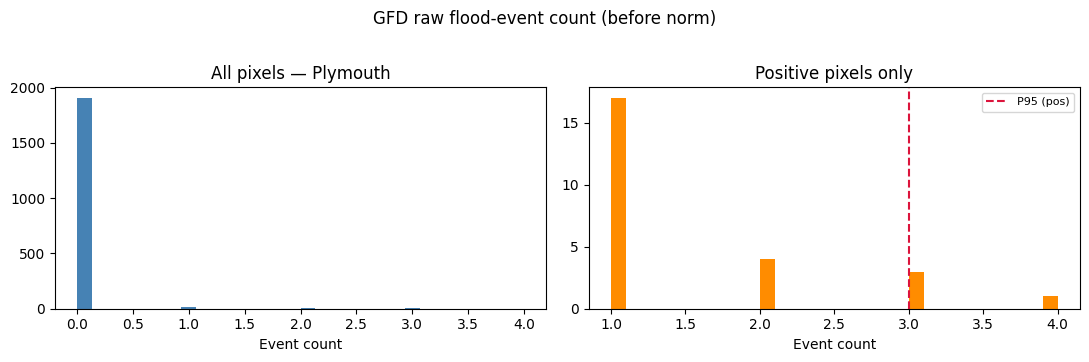

In [7]:
# Histogram of RAW flood-event counts (before robust normalization)
import numpy as np
import matplotlib.pyplot as plt

_band = "flood_event_count_no_perm_water"
_stats = flood_event_count_no_perm_water.reduceRegion(
    reducer=ee.Reducer.minMax()
        .combine(ee.Reducer.percentile([10, 25, 50, 75, 90, 95, 99]), sharedInputs=True)
        .combine(ee.Reducer.count(), sharedInputs=True)
        .combine(ee.Reducer.mean(), sharedInputs=True),
    geometry=roi,
    scale=250,
    maxPixels=1e10,
    bestEffort=True,
).getInfo()
print("Raw event-count stats (GFD):")
for k, v in sorted(_stats.items()):
    print(f"  {k}: {v}")

_sample = flood_event_count_no_perm_water.sample(
    region=roi, scale=250, numPixels=4000, seed=42, geometries=False
)
_vals = np.array(_sample.aggregate_array(_band).getInfo(), dtype=float)
_vals = _vals[np.isfinite(_vals)]
_pos = _vals[_vals > 0]
print(f"Sampled pixels: {_vals.size} | positive (flooded ≥1): {_pos.size} ({100*_pos.size/max(_vals.size,1):.1f}%)")
if _vals.size:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].hist(_vals, bins=30, color="steelblue", edgecolor="none")
    axes[0].set_title(f"All pixels — {SITE_CONFIG['display_name']}")
    axes[0].set_xlabel("Event count")
    if _pos.size:
        axes[1].hist(_pos, bins=30, color="darkorange", edgecolor="none")
        axes[1].axvline(np.percentile(_pos, 95), color="crimson", ls="--", label="P95 (pos)")
        axes[1].legend(fontsize=8)
    axes[1].set_title("Positive pixels only")
    axes[1].set_xlabel("Event count")
    plt.suptitle("GFD raw flood-event count (before norm)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No valid samples in AOI.")


# Robust normalization
Band: flood_event_count_no_perm_water

Goal: produce a 0-1 layer suitable for combination with other hazard indicators.


In [8]:
# Keep zeros as zeros, stretch only positive values to [0,1]
count = flood_event_count_no_perm_water
pos_mask = count.gt(0)
count_pos = count.updateMask(pos_mask)

# Robust cap on positive pixels only
p95 = ee.Number(
    count_pos.reduceRegion(
        reducer=ee.Reducer.percentile([95]),
        geometry=roi,
        scale=30,
        maxPixels=1e10
    ).get("flood_event_count_no_perm_water")
)

p95_safe = ee.Number(ee.Algorithms.If(p95, ee.Algorithms.If(p95.gt(0), p95, 1), 1))
count_cap = count_pos.min(p95_safe)

# log compression on positives
count_log = count_cap.add(1).log()

# min-max on positives only
mm = count_log.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=roi,
    scale=30,
    maxPixels=1e10
)

log_min = ee.Number(mm.get("flood_event_count_no_perm_water_min"))
log_max = ee.Number(mm.get("flood_event_count_no_perm_water_max"))
den = log_max.subtract(log_min)

norm_pos = ee.Image(
    ee.Algorithms.If(
        den.lte(1e-6),
        ee.Image.constant(1).updateMask(pos_mask),  # if all positives equal
        count_log.subtract(log_min).divide(den).clamp(0, 1).updateMask(pos_mask)
    )
)

# Final: zeros stay 0, positive pixels are stretched to full [0,1]
flood_event_count_norm = norm_pos.unmask(0).rename("flood_event_count_norm_0_1")


# Map check over ROI


In [9]:
m = geemap.Map()
m.centerObject(roi, 11)

count_vis = {
    'min': 0,
    'max': 20,
    'palette': ['f7fbff', 'deebf7', '9ecae1', '4292c6', '08519c']
}

once_vis = {
    'min': 0,
    'max': 1,
    'palette': ['f2f2f2', 'd7301f']
}

count_norm_vis = {
    'min': 0,
    'max': 1,
    'palette': ['f7f7f7', 'c7e9c0', '74c476', '238b45', '00441b']
}

m.addLayer(flood_event_count_no_perm_water.clip(roi), count_vis, 'Flood event count (no permanent water)')
m.addLayer(flood_observed_once.clip(roi), once_vis, 'Observed flooded >=1 event')
m.addLayer(flood_event_count_norm.clip(roi), count_norm_vis, 'Flood event count [normalized]')
m.addLayer(ee.Image().paint(roi, 1, 2), {'palette': ['yellow']}, 'ROI boundary')

m.add_legend(
    title='Observed flood extent',
    keys=['0 = never observed flooded', '1 = observed flooded >=1 event'],
    colors=['#f2f2f2', '#d7301f'],
    position='bottomright'
)

m

Map(center=[45.02238616047533, -93.4615216182928], controls=(WidgetControl(options=['position', 'transparent_b…

In [10]:
# --- Export GFD layers to site input/ (local by default) ---
# Requires: roi, flood_event_count_no_perm_water, flood_event_count_norm, flood_observed_once
# Override: export GEE_EXPORT_MODE=drive

from gee_local_export import export_image_to_input

scale_m = 30
crs = "EPSG:4326"
drive_folder = "OEF_GlobalFloodDB"

export_image_to_input(
    flood_event_count_no_perm_water.toFloat().clip(roi),
    filename=SITE_CONFIG["layers"]["gfd_count"],
    region=roi,
    scale=scale_m,
    input_dir=INPUT_DIR,
    crs=crs,
    description=f"gfd_flood_event_count_no_perm_water_{OUTPUT_PREFIX}",
    drive_folder=drive_folder,
)
export_image_to_input(
    flood_event_count_norm.toFloat().clip(roi),
    filename=SITE_CONFIG["layers"]["gfd_count_norm"],
    region=roi,
    scale=scale_m,
    input_dir=INPUT_DIR,
    crs=crs,
    description=f"gfd_flood_event_count_norm_{OUTPUT_PREFIX}",
    drive_folder=drive_folder,
)
export_image_to_input(
    flood_observed_once.toFloat().clip(roi),
    filename=SITE_CONFIG["layers"]["gfd_observed_once"],
    region=roi,
    scale=scale_m,
    input_dir=INPUT_DIR,
    crs=crs,
    description=f"gfd_flood_observed_once_{OUTPUT_PREFIX}",
    drive_folder=drive_folder,
)

print("Exports complete. Files land under:", INPUT_DIR)


[local] exporting gfd_flood_event_count_no_perm_water_plymouth.tif → /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/gfd_flood_event_count_no_perm_water_plymouth.tif (scale=30m, crs=EPSG:4326)
Generating URL ...
Please wait ...
Data downloaded to /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/gfd_flood_event_count_no_perm_water_plymouth.tif
[local] wrote /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/gfd_flood_event_count_no_perm_water_plymouth.tif (0.00 MB)
[local] exporting gfd_flood_event_count_no_perm_water_norm_plymouth.tif → /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/gfd_flood_event_count_no_perm_water_norm_plymouth.tif (scale=30m, crs=EPSG:4326)
Generating URL ...
Please wait ...
Data downloaded to /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/i

#### Step 6. Convert GFD Layers to COG and Generate Tiles

Publish the local Global Flood Database rasters for web maps: COG + colorized XYZ tiles + value-encoded XYZ tiles for hover lookup.

Inputs:
- `sites/<site_slug>/data/input/gfd_flood_event_count_no_perm_water_poa.tif`
- `sites/<site_slug>/data/input/gfd_flood_observed_once_poa.tif`

Requires GDAL CLI (`gdal_translate`, `gdaldem`, `gdal_calc.py`, `gdal2tiles.py`) and the matching color tables in `data/`.

In [ ]:
# Convert GFD GeoTIFFs to COG + visual tiles + value tiles
# Inputs expected after downloading the Earth Engine exports from Google Drive.
from pathlib import Path
import shutil
import subprocess


def find_floods_root(start: Path = Path.cwd()) -> Path:
    for path in [start, *start.parents]:
        if path.name == "floods" and (path / "script").exists():
            return path
    return FLOODS_ROOT


def resolve_gdal2tiles_python() -> str:
    gdal2tiles = shutil.which("gdal2tiles.py")
    if not gdal2tiles:
        raise RuntimeError("gdal2tiles.py not found in PATH. Install GDAL (e.g. brew install gdal).")

    gdal2tiles_python = None
    with open(gdal2tiles, "r", encoding="utf-8", errors="ignore") as f:
        first_line = f.readline().strip()
    if first_line.startswith("#!"):
        shebang_parts = first_line[2:].split()
        if shebang_parts:
            if shebang_parts[0].endswith("env") and len(shebang_parts) > 1:
                gdal2tiles_python = shutil.which(shebang_parts[1])
            else:
                gdal2tiles_python = shebang_parts[0]
    if not gdal2tiles_python:
        gdal2tiles_python = shutil.which("python3") or shutil.which("python")
    subprocess.run([gdal2tiles_python, "-c", "import numpy"], check=True, capture_output=True)
    return gdal2tiles_python


def publish_discrete_gfd_layer(layer: dict, gdal2tiles_python: str, zoom: str = "8-15") -> None:
    in_tif = layer["in_tif"]
    out_dir = layer["out_dir"]
    colors_txt = layer["colors_txt"]
    slug = layer["slug"]
    label = layer["label"]
    units = layer["units"]

    cog_tif = out_dir / f"{slug}_cog.tif"
    colorized_tif = out_dir / f"{slug}_colorized.tif"
    value_encoded_tif = out_dir / f"{slug}_value_encoded_rgb.tif"
    tiles_dir = out_dir / "tiles_visual"
    value_tiles_dir = out_dir / "tiles_values"
    decode_txt = out_dir / f"{slug}_value_tiles_decode.txt"

    out_dir.mkdir(parents=True, exist_ok=True)
    if not in_tif.exists():
        raise FileNotFoundError(f"Missing input raster: {in_tif}")
    if not colors_txt.exists():
        raise FileNotFoundError(f"Missing color table: {colors_txt}")

    print(f"\nPublishing {label}")
    print("Input:", in_tif)
    print("Output dir:", out_dir)

    # 1) COG preserving raw discrete values.
    subprocess.run([
        "gdal_translate", str(in_tif), str(cog_tif),
        "-of", "COG",
        "-ot", "Float32",
        "-co", "COMPRESS=DEFLATE",
        "-co", "RESAMPLING=NEAREST",
        "-co", "OVERVIEWS=AUTO",
    ], check=True)
    print("Created COG:", cog_tif)

    # 2) Colorized raster + visual XYZ tiles.
    subprocess.run([
        "gdaldem", "color-relief",
        str(cog_tif), str(colors_txt), str(colorized_tif),
        "-alpha",
    ], check=True)
    print("Created colorized raster:", colorized_tif)

    tiles_dir.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "gdal2tiles.py",
        "-r", "near",
        "-z", zoom,
        "--xyz",
        "-w", "none",
        str(colorized_tif),
        str(tiles_dir),
    ], check=True)
    print("Visual tiles:", tiles_dir)

    # 3) Value tiles for client-side hover.
    # Encodes integer values plus 1 so encoded RGB value 0 can mean nodata.
    # Decode: encoded = R + 256*G + 65536*B; value = encoded - 1; encoded == 0 => nodata.
    base_expr = (
        "numpy.where(numpy.isnan(A), 0, "
        "numpy.rint(numpy.clip(A,0,16777214)).astype(numpy.int64) + 1)"
    )
    subprocess.run([
        "gdal_calc.py",
        "-A", str(cog_tif),
        "--calc", f"bitwise_and({base_expr},255)",
        "--calc", f"bitwise_and(right_shift({base_expr},8),255)",
        "--calc", f"bitwise_and(right_shift({base_expr},16),255)",
        "--type", "Byte",
        "--NoDataValue", "0",
        "--overwrite",
        "--outfile", str(value_encoded_tif),
    ], check=True)

    value_tiles_dir.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "gdal2tiles.py",
        "-r", "near",
        "-z", zoom,
        "--xyz",
        "-w", "none",
        str(value_encoded_tif),
        str(value_tiles_dir),
    ], check=True)

    metadata = f"""{label} value tiles

Source raster: {in_tif.relative_to(PROJECT_ROOT)}
COG: {cog_tif.relative_to(PROJECT_ROOT)}
Visual tiles: {tiles_dir.relative_to(PROJECT_ROOT)}/{{z}}/{{x}}/{{y}}.png
Value tiles: {value_tiles_dir.relative_to(PROJECT_ROOT)}/{{z}}/{{x}}/{{y}}.png

Value tile encoding:
encoded = R + 256 * G + 65536 * B
if encoded == 0: value is nodata
else: value = encoded - 1

Units: {units}
"""
    decode_txt.write_text(metadata, encoding="utf-8")

    print("Value tiles:", value_tiles_dir)
    print("Decode metadata:", decode_txt)
    print("Decode: encoded = R + 256*G + 65536*B; value = encoded - 1; encoded 0 = nodata")


PROJECT_ROOT = FLOODS_ROOT
gdal2tiles_python = resolve_gdal2tiles_python()

layers = [
    {
        "slug": "gfd_flood_event_count_no_perm_water",
        "label": "GFD flood event count excluding permanent water",
        "units": "observed flood-event count, excluding permanent water",
        "in_tif": INPUT_DIR / SITE_CONFIG["layers"]["gfd_count"],
        "out_dir": OUT_ROOT / "gfd_flood_event_count_no_perm_water",
        "colors_txt": STYLES_DIR / "gfd_flood_event_count_no_perm_water_colors.txt",
    },
    {
        "slug": "gfd_flood_observed_once",
        "label": "GFD observed flooded at least once",
        "units": "binary flag: 0 = never observed flooded, 1 = observed flooded at least once",
        "in_tif": INPUT_DIR / SITE_CONFIG["layers"]["gfd_observed_once"],
        "out_dir": OUT_ROOT / "gfd_flood_observed_once",
        "colors_txt": STYLES_DIR / "gfd_flood_observed_once_colors.txt",
    },
]

for layer in layers:
    publish_discrete_gfd_layer(layer, gdal2tiles_python)